In [17]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

In [19]:
import joblib

# RetailPulse – Customer Churn Prediction

## Machine Learning using Random Forest

**Author:** Gulafsha

### Objective

Predict customers who are likely to stop purchasing based on their historical purchasing behavior.

### Business Goals

- Identify churn-prone customers.
- Improve customer retention.
- Support targeted marketing campaigns.
- Increase customer lifetime value.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [2]:
rfm = pd.read_csv("../data/customer_features.csv")

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
0,12346.0,165,11,372.86,70,372.86,11,26,33.896364
1,12347.0,3,2,1323.32,828,1323.32,2,70,661.660000
2,12348.0,74,1,222.16,373,222.16,1,20,222.160000
3,12349.0,43,3,2671.14,993,2671.14,3,90,890.380000
4,12351.0,11,1,300.93,261,300.93,1,21,300.930000


## Create Churn Target

Customers with Recency greater than 180 days are considered churned.

In [3]:
rfm["Churn"] = np.where(
    rfm["Recency"] > 180,
    1,
    0
)

rfm["Churn"].value_counts()

Churn
0    3487
1     825
Name: count, dtype: int64

## Feature Selection

The most important customer behaviour variables are selected as input features for the machine learning model.

In [4]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Invoice_Count",
    "Unique_Products",
    "Average_Order_Value"
]

X = rfm[features]

y = rfm["Churn"]

## Train-Test Split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3449, 7)
(863, 7)


## Train Random Forest Model

Random Forest is used to classify customers into Active or Churned categories.

In [6]:
model = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

model.fit(X_train, y_train)

print("Random Forest Trained Successfully ✅")

Random Forest Trained Successfully ✅


In [26]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open("../models/random_forest_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Random Forest model saved successfully!")

✅ Random Forest model saved successfully!


In [20]:
# ==========================================
# Save Trained Model
# ==========================================

joblib.dump(
    model,
    "../models/churn_model.pkl"
)

print("✅ churn_model.pkl saved successfully!")

✅ churn_model.pkl saved successfully!


In [7]:
predictions = model.predict(X_test)

In [8]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


In [21]:
# ==========================================
# Save Evaluation Metrics
# ==========================================

metrics = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [accuracy]
})

metrics.to_csv(
    "../outputs/churn_metrics.csv",
    index=False
)

print("✅ churn_metrics.csv saved successfully!")

metrics

✅ churn_metrics.csv saved successfully!


,Metric,Value
0,Accuracy,1.0


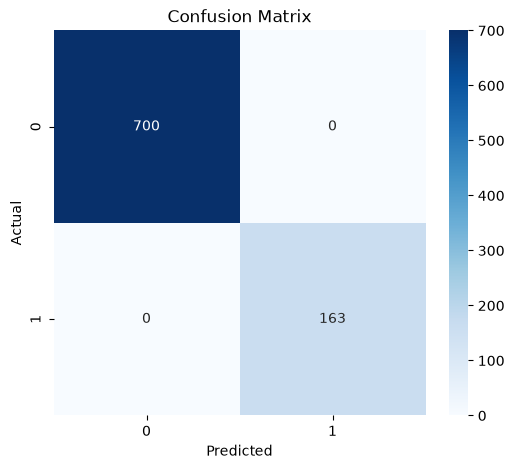

In [9]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [10]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       700
           1       1.00      1.00      1.00       163

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863



In [11]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,Recency,0.859283
1,Frequency,0.038938
4,Invoice_Count,0.034033
2,Monetary,0.025942
3,Total_Quantity,0.016079
5,Unique_Products,0.015356
6,Average_Order_Value,0.010368


In [22]:
# ==========================================
# Save Feature Importance
# ==========================================

importance.to_csv(
    "../outputs/churn_feature_importance.csv",
    index=False
)

print("✅ churn_feature_importance.csv saved successfully!")

✅ churn_feature_importance.csv saved successfully!


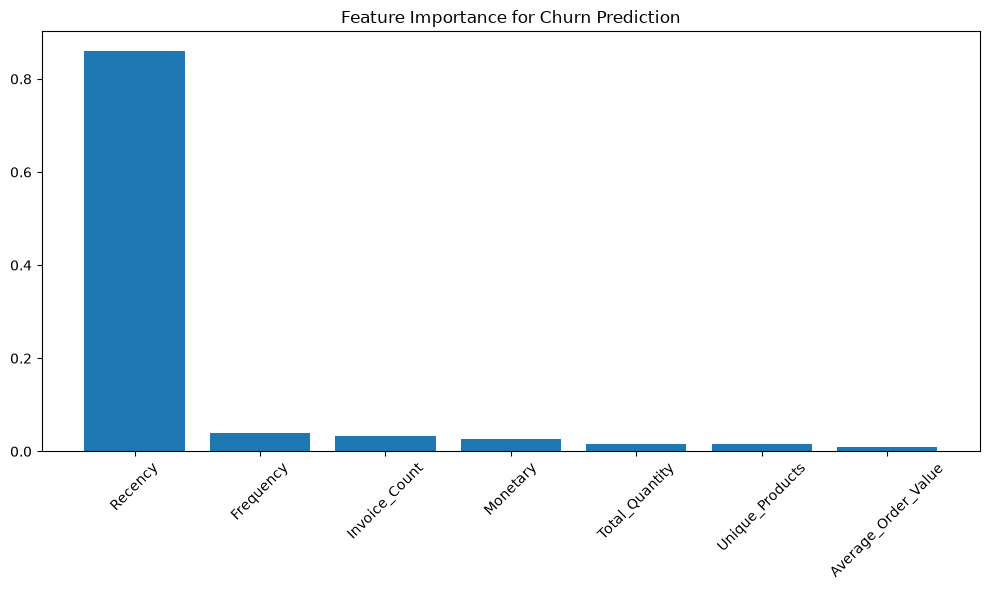

In [12]:
plt.figure(figsize=(10,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance for Churn Prediction")

plt.tight_layout()

plt.show()

In [13]:
rfm["Churn_Prediction"] = model.predict(X)

In [14]:
rfm["Churn_Status"] = rfm["Churn_Prediction"].map({
    0: "Active",
    1: "Churn Risk"
})

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value,Churn,Churn_Prediction,Churn_Status
0,12346.0,165,11,372.86,70,372.86,11,26,33.896364,0,0,Active
1,12347.0,3,2,1323.32,828,1323.32,2,70,661.660000,0,0,Active
2,12348.0,74,1,222.16,373,222.16,1,20,222.160000,0,0,Active
3,12349.0,43,3,2671.14,993,2671.14,3,90,890.380000,0,0,Active
4,12351.0,11,1,300.93,261,300.93,1,21,300.930000,0,0,Active


In [23]:
rfm.to_csv(
    "../outputs/customer_churn_predictions.csv",
    index=False
)

print("✅ customer_churn_predictions.csv saved successfully!")

✅ customer_churn_predictions.csv saved successfully!


# Business Insights

### Key Findings

- Customers with high Recency are more likely to churn.
- Frequency and Monetary value are strong indicators of customer loyalty.
- Feature importance identifies the variables that contribute most to churn prediction.
- Churn predictions can support targeted retention campaigns.
- Early identification of churn risk helps reduce customer loss and improve lifetime value.

# Conclusion

A Random Forest classifier was successfully trained to identify customers at risk of churn.

The generated predictions can be integrated into:

- Streamlit Dashboard
- Power BI Dashboard
- CRM Systems
- Marketing Automation

The exported prediction files support downstream analytics and business decision-making.